# On Analyzing Real World Time Series using the Wesad Dataset

In [1]:
import os
import sys

import numpy as np
import pandas as pd

from tqdm import tqdm
# Get the current working directory of the notebook
notebook_dir = os.getcwd()
# print(notebook_dir)

# Add the parent directory to the system path
sys.path.append(os.path.join(notebook_dir, '../../framework_for_time_series_data/tslearn/'))

In [2]:
pd.set_option('max_colwidth', 800)
# pd.set_option('display.max_columns', None)
# pd.set_option('display.max_rows', None)

## Load Single Subject

In [3]:
base_path = os.path.join(notebook_dir, '../../../../')
dataset_path = "startups/roeh-health/data/WESAD/"
relative_path = os.path.join(base_path, dataset_path)
dataset_path = f"{relative_path}S2/S2.pkl"

data = pd.read_pickle(dataset_path)
data

{'signal': {'chest': {'ACC': array([[ 0.95539999, -0.222     , -0.55799997],
          [ 0.92579997, -0.2216    , -0.55379999],
          [ 0.90820003, -0.21960002, -0.53920001],
          ...,
          [ 0.87179995, -0.12379998, -0.30419999],
          [ 0.87300003, -0.12339997, -0.30260003],
          [ 0.87020004, -0.12199998, -0.30220002]]),
   'ECG': array([[ 0.02142334],
          [ 0.02032471],
          [ 0.01652527],
          ...,
          [-0.00544739],
          [ 0.00013733],
          [ 0.0040741 ]]),
   'EMG': array([[-0.00444031],
          [ 0.00434875],
          [ 0.00517273],
          ...,
          [-0.01716614],
          [-0.02897644],
          [-0.02357483]]),
   'EDA': array([[5.25054932],
          [5.26733398],
          [5.24330139],
          ...,
          [0.36048889],
          [0.36582947],
          [0.365448  ]]),
   'Temp': array([[30.120758],
          [30.129517],
          [30.138214],
          ...,
          [31.459229],
          [31.484283

In [4]:
signal_data = data['signal']
label_data = data['label']
subject_data = data['subject']

### Load Chest Signals

In [5]:
def extract_chest_signals(signal_data, subject_data, label_data):
    chest_signal = signal_data['chest']
    chest_acc = pd.DataFrame(chest_signal['ACC'], columns=['ACC_x', 'ACC_y', 'ACC_z'])
    chest_ecg = pd.DataFrame(chest_signal['ECG'], columns=['ECG'])
    chest_emg = pd.DataFrame(chest_signal['EMG'], columns=['EMG'])
    chest_eda = pd.DataFrame(chest_signal['EDA'], columns=['EDA'])
    chest_temp = pd.DataFrame(chest_signal['Temp'], columns=['Temp'])
    chest_resp = pd.DataFrame(chest_signal['Resp'], columns=['Resp'])
    
    # Combine all DataFrames
    df_chest = pd.concat([chest_acc, chest_ecg, chest_emg, chest_eda, chest_temp, chest_resp], axis=1)
    
    # Add inside so it can stand alone (without wrist)
    df_chest['subject'] = subject_data
    df_chest['label'] = label_data

    return df_chest

In [6]:
# Create DataFrames
df_chest = extract_chest_signals(signal_data, label_data, subject_data)

In [7]:
df_chest

,ACC_x,ACC_y,ACC_z,ECG,EMG,EDA,Temp,Resp,subject,label
0,0.9554,-0.2220,-0.5580,0.021423,-0.004440,5.250549,30.120758,-1.148987,0,S2
1,0.9258,-0.2216,-0.5538,0.020325,0.004349,5.267334,30.129517,-1.124573,0,S2
2,0.9082,-0.2196,-0.5392,0.016525,0.005173,5.243301,30.138214,-1.152039,0,S2
3,0.8974,-0.2102,-0.5122,0.016708,0.007187,5.249405,30.129517,-1.158142,0,S2
4,0.8882,-0.2036,-0.4824,0.011673,-0.015152,5.286407,30.130951,-1.161194,0,S2
...,...,...,...,...,...,...,...,...,...,...
4255295,0.8750,-0.1234,-0.2974,-0.013138,0.020370,0.400162,31.457733,-1.063538,0,S2
4255296,0.8750,-0.1262,-0.2988,-0.010345,0.019592,0.355911,31.476898,-1.106262,0,S2
4255297,0.8718,-0.1238,-0.3042,-0.005447,-0.017166,0.360489,31.459229,-1.103210,0,S2
4255298,0.8730,-0.1234,-0.3026,0.000137,-0.028976,0.365829,31.484283,-1.086426,0,S2


<Axes: >

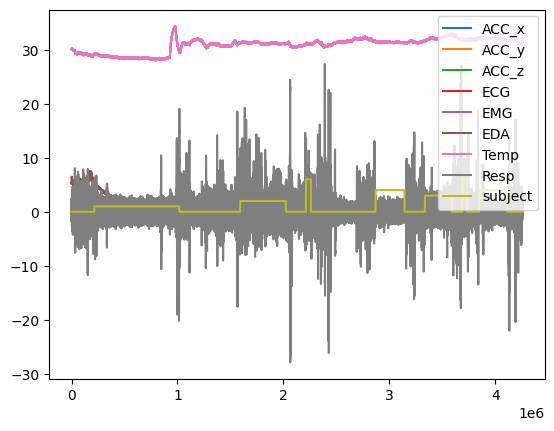

In [8]:
df_chest.plot()

### Load Wrist Signals

In [9]:
def extract_wrist_signals(signal_data, subject_data):
    wrist_signal = signal_data['wrist']
    wrist_acc = pd.DataFrame(wrist_signal['ACC'], columns=['ACC_x', 'ACC_y', 'ACC_z'])
    wrist_bvp = pd.DataFrame(wrist_signal['BVP'], columns=['BVP'])
    wrist_eda = pd.DataFrame(wrist_signal['EDA'], columns=['EDA'])
    wrist_temp = pd.DataFrame(wrist_signal['TEMP'], columns=['Temp'])
    
    # Combine all DataFrames
    wrist_df = pd.concat([wrist_acc, wrist_bvp, wrist_eda, wrist_temp], axis=1)
    
    # Add inside so it can stand alone (without chest)
    wrist_df['subject'] = subject_data

    return wrist_df

In [10]:
wrist_df = extract_wrist_signals(signal_data, subject_data)

In [11]:
wrist_df

,ACC_x,ACC_y,ACC_z,BVP,EDA,Temp,subject
0,62.0,-21.0,107.0,-59.37,1.138257,35.41,S2
1,66.0,13.0,53.0,-53.42,1.125444,35.41,S2
2,41.0,9.0,15.0,-44.40,1.011405,35.41,S2
3,52.0,16.0,24.0,-33.17,1.033188,35.41,S2
4,54.0,15.0,34.0,-20.79,0.935807,35.41,S2
...,...,...,...,...,...,...,...
389051,NaN,NaN,NaN,18.33,NaN,NaN,S2
389052,NaN,NaN,NaN,18.26,NaN,NaN,S2
389053,NaN,NaN,NaN,18.26,NaN,NaN,S2
389054,NaN,NaN,NaN,18.68,NaN,NaN,S2


<Axes: >

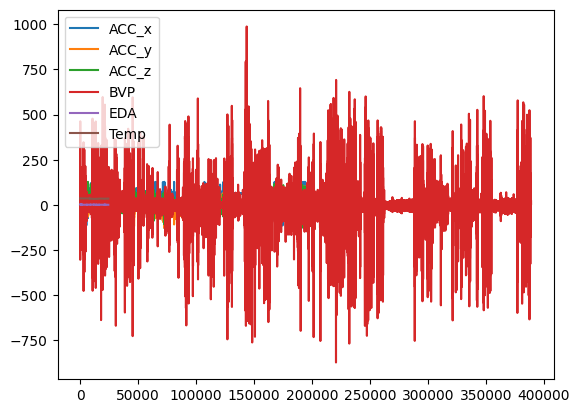

In [12]:
wrist_df.plot()

## Load All Subjects

In [17]:
def load_wesad_dataset(relative_path, subject_ids):
    chest_dfs = []
    wrist_dfs = []

    for sid in tqdm(subject_ids):
        dataset_path = f"{relative_path}{sid}/{sid}.pkl"
        # print(dataset_path)

        data = pd.read_pickle(dataset_path)
        signal_data = data['signal']
        label_data = data['label']
        subject_data = data['subject']
        chest_df = extract_chest_signals(signal_data, subject_data, label_data)
        wrist_df = extract_wrist_signals(signal_data, subject_data)
        chest_dfs.append(chest_df)
        wrist_dfs.append(wrist_df)

        all_chest_dfs = pd.concat(chest_dfs)
        all_wrist_dfs = pd.concat(wrist_dfs)
    return all_chest_dfs, all_wrist_dfs
        

In [18]:
subject_ids = [f"S{i}" for i in range(2, 18) if i != 12]
chest_df, wrist_df = load_wesad_dataset(relative_path, subject_ids)

100%|██████████| 15/15 [00:29<00:00,  1.95s/it]


In [15]:
chest_df

,ACC_x,ACC_y,ACC_z,ECG,EMG,EDA,Temp,Resp,subject,label
0,0.9554,-0.2220,-0.5580,0.021423,-0.004440,5.250549,30.120758,-1.148987,S2,0
1,0.9258,-0.2216,-0.5538,0.020325,0.004349,5.267334,30.129517,-1.124573,S2,0
2,0.9082,-0.2196,-0.5392,0.016525,0.005173,5.243301,30.138214,-1.152039,S2,0
3,0.8974,-0.2102,-0.5122,0.016708,0.007187,5.249405,30.129517,-1.158142,S2,0
4,0.8882,-0.2036,-0.4824,0.011673,-0.015152,5.286407,30.130951,-1.161194,S2,0
...,...,...,...,...,...,...,...,...,...,...
4143995,0.9006,-0.0400,-0.1898,0.173676,-0.005539,7.265091,33.862762,0.318909,S17,0
4143996,0.9022,-0.0398,-0.1872,0.168777,-0.004944,7.266617,33.859741,0.233459,S17,0
4143997,0.9028,-0.0424,-0.1864,0.167130,-0.016068,7.262802,33.864288,0.318909,S17,0
4143998,0.9002,-0.0408,-0.1854,0.170334,0.005173,7.269669,33.862762,0.308228,S17,0


In [16]:
wrist_df

,ACC_x,ACC_y,ACC_z,BVP,EDA,Temp,subject
0,62.0,-21.0,107.0,-59.37,1.138257,35.41,S2
1,66.0,13.0,53.0,-53.42,1.125444,35.41,S2
2,41.0,9.0,15.0,-44.40,1.011405,35.41,S2
3,52.0,16.0,24.0,-33.17,1.033188,35.41,S2
4,54.0,15.0,34.0,-20.79,0.935807,35.41,S2
...,...,...,...,...,...,...,...
378875,NaN,NaN,NaN,-2.09,NaN,NaN,S17
378876,NaN,NaN,NaN,-3.28,NaN,NaN,S17
378877,NaN,NaN,NaN,-4.43,NaN,NaN,S17
378878,NaN,NaN,NaN,-5.44,NaN,NaN,S17
